In [ ]:
import pandas as pd
import numpy as np

print("¡Entorno configurado correctamente!")

In [ ]:
import pandas as pd
import numpy as np

# Creamos 720 horas de datos simulados (1 mes)
horas = pd.date_range(start="2026-08-01", periods=720, freq="h")

# Generamos caudales y temperaturas realistas con pequeñas variaciones
np.random.seed(42)
caudal_lmin = np.random.uniform(15.0, 45.0, size=720) # Caudal en l/min
temp_hot_in = np.random.uniform(70.0, 85.0, size=720)  # Temp entrada caliente (ºC)
temp_cold_in = np.random.uniform(15.0, 22.0, size=720) # Temp entrada fría (ºC)

# Creamos nuestra tabla de datos (DataFrame)
df = pd.DataFrame({
    'Fecha_Hora': horas,
    'Caudal_lmin': caudal_lmin,
    'Temp_Hot_In_C': temp_hot_in,
    'Temp_Cold_In_C': temp_cold_in
})

# Guardamos los datos en un archivo CSV local
df.to_csv('datos_simulacion_termica.csv', index=False)

# Mostramos las primeras 5 filas de la tabla
df.head()

In [ ]:
import os
print(os.getcwd())

In [ ]:
import pandas as pd

# 1. Cargamos el archivo CSV que creaste antes
df = pd.read_csv('datos_simulacion_termica.csv')

# 2. Definimos nuestra función matemática
def calcular_eficiencia(caudal):
    # Simulamos que a mayor caudal (l/min), la eficiencia cae ligeramente
    eficiencia = 0.90 - (caudal * 0.002)
    return eficiencia

# 3. Aplicamos la fórmula a toda la columna de caudales a la vez
df['Eficiencia'] = df['Caudal_lmin'].apply(calcular_eficiencia)

# 4. Calculamos la temperatura de salida del fluido frío
df['Temp_Cold_Out_C'] = df['Temp_Cold_In_C'] + df['Eficiencia'] * (df['Temp_Hot_In_C'] - df['Temp_Cold_In_C'])

# Mostramos los primeros resultados para comprobar que ha funcionado
df.head()

In [ ]:
# Guardamos la tabla con todos los cálculos térmicos en un nuevo archivo
df.to_csv('resultados_simulacion_termica.csv', index=False)

In [ ]:
import numpy as np

# 1. Calculamos la T de salida del fluido caliente (por balance de energía simple)
df['Temp_Hot_Out_C'] = df['Temp_Hot_In_C'] - (df['Temp_Cold_Out_C'] - df['Temp_Cold_In_C'])

# 2. Definimos la Temperatura ambiente de referencia (25ºC) en Kelvin
T0 = 298.15 

# Convertimos todas las columnas a Kelvin sumando 273.15 directamente
Th_in_K = df['Temp_Hot_In_C'] + 273.15
Th_out_K = df['Temp_Hot_Out_C'] + 273.15
Tc_in_K = df['Temp_Cold_In_C'] + 273.15
Tc_out_K = df['Temp_Cold_Out_C'] + 273.15

# 3. Calculamos la exergía destruida proporcional usando el logaritmo neperiano (np.log)
# Ecuación: Ed = T0 * [ ln(Th_out / Th_in) + ln(Tc_out / Tc_in) ]
df['Exergia_Destruida'] = T0 * (np.log(Th_out_K / Th_in_K) + np.log(Tc_out_K / Tc_in_K))

# Mostramos cómo ha quedado nuestra tabla final con todos los cálculos termodinámicos
df.head()

In [ ]:
df.to_csv('resultados_simulacion_termica.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura para que contenga 2 gráficas alineadas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.set_title('Evolución de Temperaturas (Primeros 4 Días)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Temperatura (ºC)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df['Fecha_Hora'] = pd.to_datetime(df['Fecha_Hora'])

# 2. Configuramos el tamaño de la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- GRÁFICA 1: Perfil de temperaturas ---
ax1.plot(df['Fecha_Hora'][:96], df['Temp_Hot_In_C'][:96], label='T. Entrada Caliente (ºC)', color='#d95f02', linewidth=1.5)
ax1.plot(df['Fecha_Hora'][:96], df['Temp_Cold_Out_C'][:96], label='T. Salida Fría (ºC)', color='#7570b3', linewidth=1.5)

ax1.set_title('Evolución de Temperaturas (Primeros 4 Días)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Temperatura (ºC)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax1.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate() 

# Guardamos la imagen y la mostramos
plt.savefig('analisis_termico_graficas.png', dpi=300, bbox_inches='tight')
plt.show()

# --- GRÁFICA 2: Relación del Caudal con la Exergía Destruida ---
ax2.scatter(df['Caudal_lmin'], df['Exergia_Destruida'], color='#1b9e77', alpha=0.5, edgecolors='none')

ax2.set_title('Impacto del Caudal en la Destrucción de Exergía', fontsize=12, fontweight='bold')
ax2.set_xlabel('Caudal de Fluido (l/min)')
ax2.set_ylabel('Destrucción de Exergía (relativa)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajuste automático del espacio entre gráficas
plt.tight_layout()

# Mostramos el resultado en pantalla
plt.show()

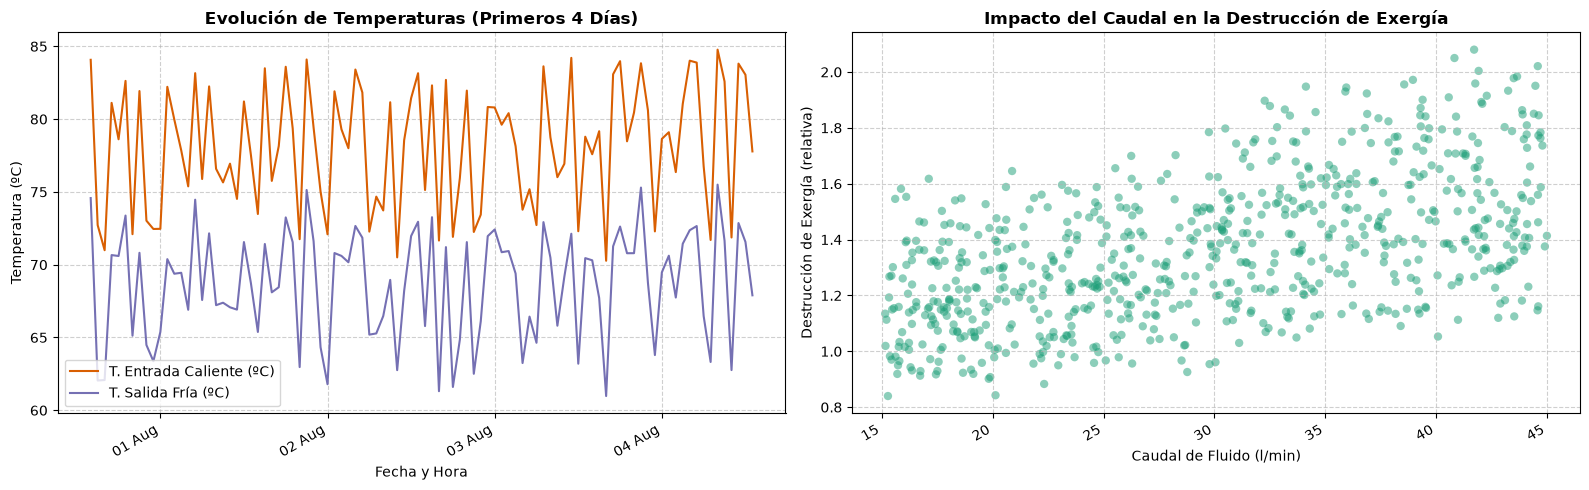

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. GENERACIÓN DE DATOS SIMULADOS
# ==========================================
# Creamos 720 horas de datos (1 mes)
horas = pd.date_range(start="2026-08-01", periods=720, freq="h")

np.random.seed(42)
caudal_lmin = np.random.uniform(15.0, 45.0, size=720)  # Caudal en l/min
temp_hot_in = np.random.uniform(70.0, 85.0, size=720)  # Temp entrada caliente (ºC)
temp_cold_in = np.random.uniform(15.0, 22.0, size=720) # Temp entrada fría (ºC)

df = pd.DataFrame({
    'Fecha_Hora': horas,
    'Caudal_lmin': caudal_lmin,
    'Temp_Hot_In_C': temp_hot_in,
    'Temp_Cold_In_C': temp_cold_in
})

# ==========================================
# 2. CÁLCULOS TERMODINÁMICOS
# ==========================================
# Función de eficiencia del intercambiador de calor sensible
def calcular_eficiencia(caudal):
    return 0.90 - (caudal * 0.002)

df['Eficiencia'] = df['Caudal_lmin'].apply(calcular_eficiencia)

# Temperaturas de salida
df['Temp_Cold_Out_C'] = df['Temp_Cold_In_C'] + df['Eficiencia'] * (df['Temp_Hot_In_C'] - df['Temp_Cold_In_C'])
df['Temp_Hot_Out_C'] = df['Temp_Hot_In_C'] - (df['Temp_Cold_Out_C'] - df['Temp_Cold_In_C'])

# Balance de Exergía (proceso de cesión de calor)
T0 = 298.15 # Temperatura ambiente de referencia en K

Th_in_K = df['Temp_Hot_In_C'] + 273.15
Th_out_K = df['Temp_Hot_Out_C'] + 273.15
Tc_in_K = df['Temp_Cold_In_C'] + 273.15
Tc_out_K = df['Temp_Cold_Out_C'] + 273.15

df['Exergia_Destruida'] = T0 * (np.log(Th_out_K / Th_in_K) + np.log(Tc_out_K / Tc_in_K))

# Guardamos los resultados completos en tu disco duro
df.to_csv('results_thermal_simulation.csv', index=False)

# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================
# Aseguramos que la columna de fechas esté en formato datetime para evitar solapamientos
df['Fecha_Hora'] = pd.to_datetime(df['Fecha_Hora'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- GRÁFICA 1: Perfil de Temperaturas ---
ax1.plot(df['Fecha_Hora'][:96], df['Temp_Hot_In_C'][:96], label='T. Entrada Caliente (ºC)', color='#d95f02', linewidth=1.5)
ax1.plot(df['Fecha_Hora'][:96], df['Temp_Cold_Out_C'][:96], label='T. Salida Fría (ºC)', color='#7570b3', linewidth=1.5)

ax1.set_title('Evolución de Temperaturas (Primeros 4 Días)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Temperatura (ºC)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Formateamos el eje X para que quede limpio
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate()

# --- GRÁFICA 2: Dispersión Caudal vs Exergía ---
ax2.scatter(df['Caudal_lmin'], df['Exergia_Destruida'], color='#1b9e77', alpha=0.5, edgecolors='none')

ax2.set_title('Impacto del Caudal en la Destrucción de Exergía', fontsize=12, fontweight='bold')
ax2.set_xlabel('Caudal de Fluido (l/min)')
ax2.set_ylabel('Destrucción de Exergía (relativa)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajustes finales y renderizado
plt.tight_layout()
plt.savefig('thermal_analysis_graphics.png', dpi=300, bbox_inches='tight')
plt.show()

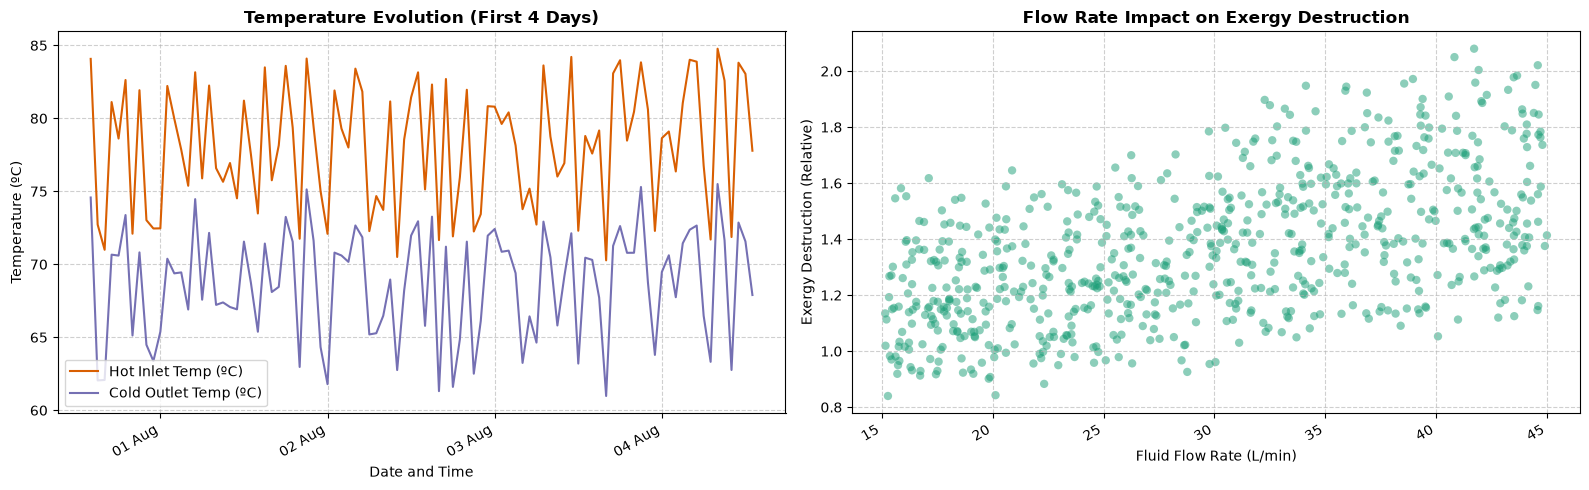

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. DATA GENERATION
# ==========================================
# 720 hours (1 month)
hours = pd.date_range(start="2026-08-01", periods=720, freq="h")

np.random.seed(42)
flow_rate_lmin = np.random.uniform(15.0, 45.0, size=720)  # Flow rate in L/min
temp_hot_in = np.random.uniform(70.0, 85.0, size=720)  # Hot inlet temp (ºC)
temp_cold_in = np.random.uniform(15.0, 22.0, size=720) # Cold inlet temp (ºC)

df = pd.DataFrame({
    'Date_Time': hours,
    'Flow_Rate_Lmin': flow_rate_lmin,
    'Temp_Hot_In_C': temp_hot_in,
    'Temp_Cold_In_C': temp_cold_in
})

# ==========================================
# 2. THERMODYNAMIC CALCULATIONS
# ==========================================
# Sensible heat exchanger efficiency function
def calculate_efficiency(flow_rate):
    return 0.90 - (flow_rate * 0.002)

df['Efficiency'] = df['Flow_Rate_Lmin'].apply(calculate_efficiency)

# Outlet temperatures
df['Temp_Cold_Out_C'] = df['Temp_Cold_In_C'] + df['Efficiency'] * (df['Temp_Hot_In_C'] - df['Temp_Cold_In_C'])
df['Temp_Hot_Out_C'] = df['Temp_Hot_In_C'] - (df['Temp_Cold_Out_C'] - df['Temp_Cold_In_C'])

# Exergy Balance (Heat transfer process)
T0 = 298.15 # Reference environment temperature in K

Th_in_K = df['Temp_Hot_In_C'] + 273.15
Th_out_K = df['Temp_Hot_Out_C'] + 273.15
Tc_in_K = df['Temp_Cold_In_C'] + 273.15
Tc_out_K = df['Temp_Cold_Out_C'] + 273.15

df['Exergy_Destruction'] = T0 * (np.log(Th_out_K / Th_in_K) + np.log(Tc_out_K / Tc_in_K))

# Save the final dataset with the new English filename
df.to_csv('results_thermal_simulation.csv', index=False)

# ==========================================
# 3. DATA VISUALIZATION
# ==========================================
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- PLOT 1: Temperature Profile ---
ax1.plot(df['Date_Time'][:96], df['Temp_Hot_In_C'][:96], label='Hot Inlet Temp (ºC)', color='#d95f02', linewidth=1.5)
ax1.plot(df['Date_Time'][:96], df['Temp_Cold_Out_C'][:96], label='Cold Outlet Temp (ºC)', color='#7570b3', linewidth=1.5)

ax1.set_title('Temperature Evolution (First 4 Days)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date and Time')
ax1.set_ylabel('Temperature (ºC)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax1.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate()

# --- PLOT 2: Flow Rate vs Exergy Destruction ---
ax2.scatter(df['Flow_Rate_Lmin'], df['Exergy_Destruction'], color='#1b9e77', alpha=0.5, edgecolors='none')

ax2.set_title('Flow Rate Impact on Exergy Destruction', fontsize=12, fontweight='bold')
ax2.set_xlabel('Fluid Flow Rate (L/min)')
ax2.set_ylabel('Exergy Destruction (Relative)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Save the graphics with the new English filename
plt.tight_layout()
plt.savefig('thermal_analysis_graphics.png', dpi=300, bbox_inches='tight')
plt.show()